# Carregando dados

In [1]:
# Instalação das dependências e carga do dataset

import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

dataset = load_dataset("zefang-liu/phishing-email-dataset")

# O dataset vem num único split chamado 'train'
df = dataset["train"].to_pandas()
print(f"Dataset carregado com sucesso! Shape: {df.shape}")

df.head()

Dataset carregado com sucesso! Shape: (18650, 3)


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [2]:
print("INFORMAÇÕES GERAIS")
print(df.info())

# Tipos únicos de label
print("\n Classes presentes:")
print(df["Email Type"].value_counts())

# Verificar valores nulos
print("\n Valores nulos por coluna:")
print(df.isnull().sum())

# Verificar linhas com texto vazio ou nulo 
df = df.dropna(subset=["Email Text"])         # remove NaN
df = df[df["Email Text"].str.strip() != ""]   # remove strings vazias
print(f"\n Após limpeza de nulos/vazios: {df.shape[0]} registros")

INFORMAÇÕES GERAIS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  18650 non-null  int64 
 1   Email Text  18634 non-null  object
 2   Email Type  18650 non-null  object
dtypes: int64(1), object(2)
memory usage: 437.2+ KB
None

 Classes presentes:
Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

 Valores nulos por coluna:
Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64

 Após limpeza de nulos/vazios: 18631 registros


# Padronizar e binarizar

In [3]:
# Convertemos "Phishing Email" = 1 e "Safe Email" = 0

df["label"] = df["Email Type"].map({
    "Phishing Email": 1,
    "Safe Email":     0
})

print("Coluna 'label' criada:")
print(df[["Email Type", "label"]].value_counts())

df[["Email Text", "Email Type", "label"]].head()

Coluna 'label' criada:
Email Type      label
Safe Email      0        11322
Phishing Email  1         7309
Name: count, dtype: int64


,Email Text,Email Type,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email,0
1,the other side of * galicismos * * galicismo *...,Safe Email,0
2,re : equistar deal tickets are you still avail...,Safe Email,0
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email,1
4,software at incredibly low prices ( 86 % lower...,Phishing Email,1


# Pré-processamento

In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /home/isaque/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/isaque/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/isaque/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/isaque/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/isaque/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## funções de pré-processamento

In [5]:
# palavras que identificam a ORIGEM
# dos dados, não o conteúdo real:
# ex: "enron", "university", "linguistics"

# Stopwords padrão do NLTK 
stop_words_base = set(stopwords.words("english"))

vies_dataset = {
    # Empresa Enron
    "enron", "ect", "hou", "corp", "ena",

    # Vocabulário acadêmico de linguística
    "university", "linguistics", "linguistic",
    "conference", "language", "paper", "abstract",
    "workshop", "submission", "proceedings",
}

# Ruídos de pré-processamento 
# Tokens que escaparam da limpeza mas não têm significado
ruidos = {
    "e", "u", "b", "c", "j", "n", "p", "r", "s",
    "com", "http", "www", "org", "net", "edu",
    "ect", "pm", "de", "en",
}

# Linha adicionada após analise do modelo logistic regression
vies_residual = {
    "vince", "louise", "houston", "kaminski",
    "john", "robert", "david", "mark", "mike",
    "hou", "ena", "corp",
}

# Unir tudo numa stoplist customizada 
custom_stopwords = stop_words_base | vies_dataset | ruidos | vies_residual

lemmatizer = WordNetLemmatizer()

def remove_html(text):
    """Remove tags HTML como <br>, <a href=...>, etc."""
    return re.sub(r"<[^>]+>", " ", text)

def remove_urls(text):
    """Remove URLs (http, https, www)."""
    return re.sub(r"http\S+|www\S+|https\S+", " ", text)

def remove_email_addresses(text):
    """Remove endereços de email (ex: user@domain.com)."""
    return re.sub(r"\S+@\S+", " ", text)

def remove_numbers(text):
    """Remove sequências numéricas isoladas."""
    return re.sub(r"\b\d+\b", " ", text)

def remove_special_characters(text):
    """Remove pontuação e caracteres especiais, mantendo letras e espaços."""
    return re.sub(r"[^a-zA-Z\s]", " ", text)

def normalize_whitespace(text):
    """Colapsa múltiplos espaços em um único espaço."""
    return re.sub(r"\s+", " ", text).strip()

def tokenize_and_clean(text):
    """
    Versão atualizada com stopwords customizadas.
    Substitui a função anterior tokenize_and_clean.
    """
    tokens = word_tokenize(text.lower())
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t.isalpha()                    
        and t not in custom_stopwords     
        and len(t) > 2                    
    ]
    return " ".join(tokens)

def preprocess(text):
    """
    Pipeline completo.
    """
    if not isinstance(text, str):
        return ""
    text = remove_html(text)
    text = remove_urls(text)
    text = remove_email_addresses(text)
    text = remove_numbers(text)
    text = remove_special_characters(text)
    text = normalize_whitespace(text)
    text = tokenize_and_clean(text)    
    return text


## Aplicando pré-processamento

In [6]:
df["clean_text"] = df["Email Text"].apply(preprocess)

df['clean_text'].iloc[3][:300]

'hello hot lil horny toy one dream open minded person love talk subject fantasy way life ultimate sex play ummmmmmmmmmmmmm wet ready look imagination matter sexy voice make dream come true hurry call let cummmmm toll free teen phone billing sign free personalized mail mail'

In [7]:
# Verificar textos vazios após limpeza
# Alguns emails podem ficar vazios após a limpeza
# (ex: emails que eram só HTML ou só URLs).

vazios = df["clean_text"].str.strip().eq("").sum()
print(f"Registros com texto vazio após limpeza: {vazios}")

df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)
print(f"Dataset final: {df.shape[0]} registros")

Registros com texto vazio após limpeza: 4
Dataset final: 18627 registros


In [8]:
df.to_csv("phishing_dataset_processed.csv", index=False)
print("Dataset processado salvo em 'phishing_dataset_processed.csv'")

# df = pd.read_csv("phishing_dataset_processed.csv")

Dataset processado salvo em 'phishing_dataset_processed.csv'


# Analise exploratoria do texto limpo

Distribuição das classes:
  Safe Email: 11321 (60.8%)
  Phishing Email: 7306 (39.2%)


/tmp/ipykernel_265691/959387453.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Email Type", palette=["green", "red"], ax=axes[0])


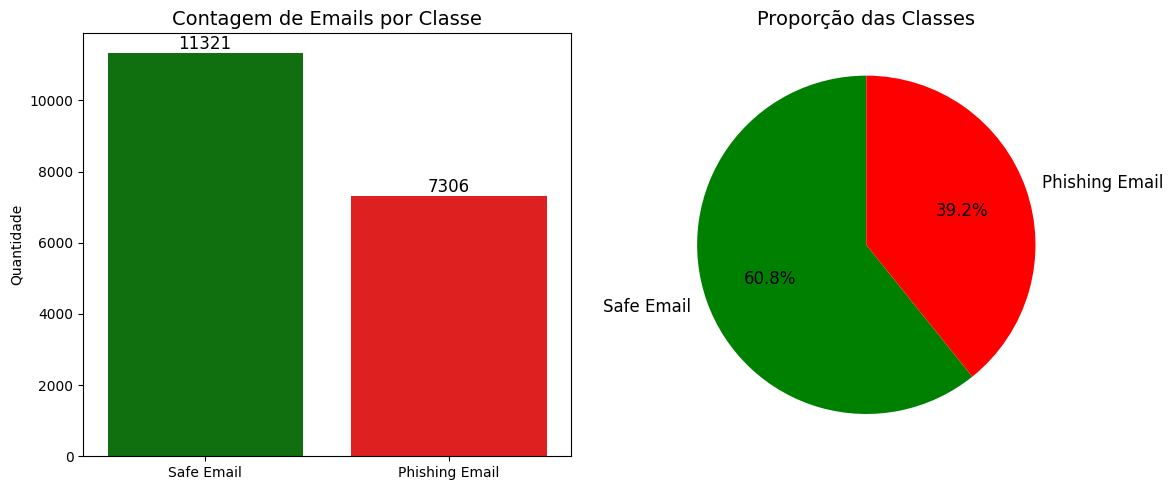

Gráfico salvo como 'distribuicao_classes.png'


In [9]:
# Distribuição das classes (balanceamento)

contagem = df["Email Type"].value_counts()
percentual = df["Email Type"].value_counts(normalize=True) * 100

print("Distribuição das classes:")
for label, count in contagem.items():
    print(f"  {label}: {count} ({percentual[label]:.1f}%)")

# Gráfico de barras 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barras
sns.countplot(data=df, x="Email Type", palette=["green", "red"], ax=axes[0])
axes[0].set_title("Contagem de Emails por Classe", fontsize=14)
axes[0].set_xlabel("")
axes[0].set_ylabel("Quantidade")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=12)

# Pizza
axes[1].pie(contagem, labels=contagem.index,
            autopct='%1.1f%%', colors=["green", "red"],
            startangle=90, textprops={"fontsize": 12})
axes[1].set_title("Proporção das Classes", fontsize=14)

plt.tight_layout()
plt.savefig("distribuicao_classes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo como 'distribuicao_classes.png'")

Estatísticas de comprimento do texto por classe:
               text_length                                              \
                     count    mean      std  min    25%    50%     75%   
Email Type                                                               
Phishing Email      7306.0   974.3   2179.0  3.0  212.0  416.0   920.0   
Safe Email         11321.0  1931.6  82709.7  4.0  236.0  524.0  1149.0   

                          word_count                                          \
                      max      count   mean      std  min   25%   50%    75%   
Email Type                                                                     
Phishing Email   100948.0     7306.0  133.5    282.1  1.0  31.0  59.0  126.0   
Safe Email      8796186.0    11321.0  259.8  10890.5  1.0  34.0  75.0  157.0   

                           
                      max  
Email Type                 
Phishing Email    11772.0  
Safe Email      1158176.0  


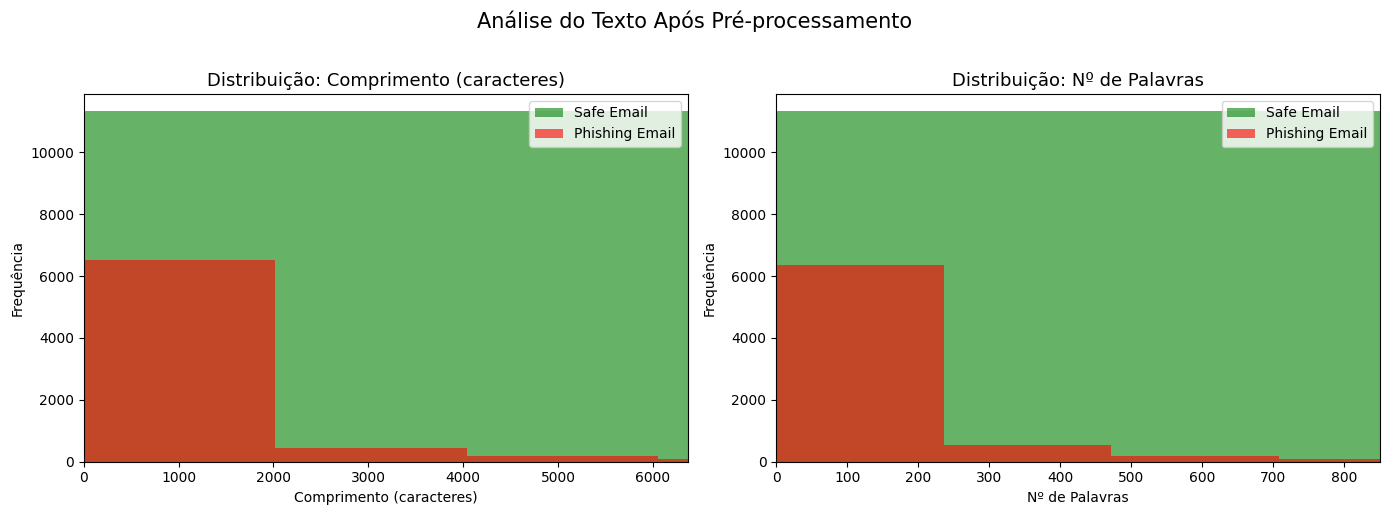

In [10]:
df["text_length"]  = df["clean_text"].apply(len)          # comprimento em caracteres
df["word_count"]   = df["clean_text"].apply(lambda x: len(x.split()))  # nº de palavras

# Estatísticas por classe 
print("Estatísticas de comprimento do texto por classe:")
print(df.groupby("Email Type")[["text_length", "word_count"]].describe().round(1))

# Distribuição visual 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ["text_length", "word_count"],
    ["Comprimento (caracteres)", "Nº de Palavras"]
):
    for label, color in [("Safe Email", "green"), ("Phishing Email", "red")]:
        subset = df[df["Email Type"] == label][col]
        ax.hist(subset, bins=50, alpha=0.6, color=color, label=label)
    ax.set_title(f"Distribuição: {title}", fontsize=13)
    ax.set_xlabel(title)
    ax.set_ylabel("Frequência")
    ax.legend()
    ax.set_xlim(0, df[col].quantile(0.98))  # remove outliers extremos do gráfico

plt.suptitle("Análise do Texto Após Pré-processamento", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("distribuicao_texto.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_265691/3412705793.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_265691/3412705793.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


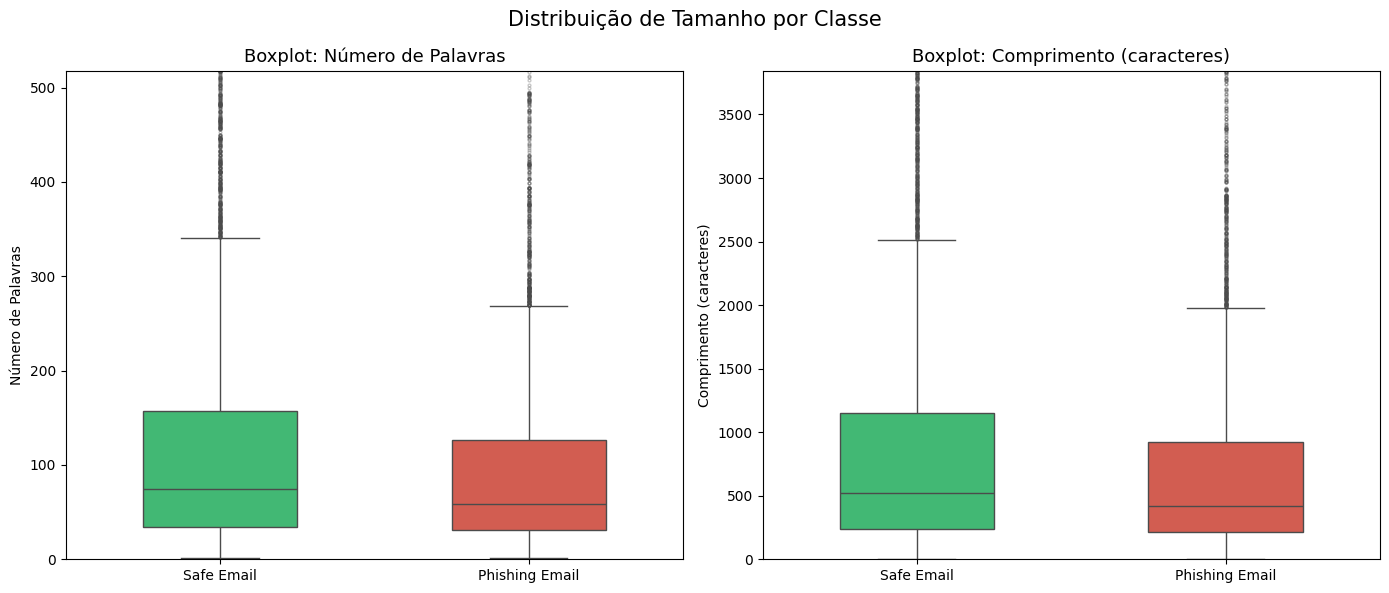

In [11]:
# Boxplot — Distribuição de tamanho por classe
# O boxplot mostra mediana, quartis e outliers.
# Bom para comparar se phishing tende a ser mais curto/longo.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, title in zip(
    axes,
    ["word_count", "text_length"],
    ["Número de Palavras", "Comprimento (caracteres)"]
):
    sns.boxplot(
        data=df,
        x="Email Type",
        y=col,
        palette={"Safe Email": "#2ecc71", "Phishing Email": "#e74c3c"},
        ax=ax,
        width=0.5,
        flierprops={"marker": "o", "markersize": 2, "alpha": 0.3}
    )
    ax.set_title(f"Boxplot: {title}", fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel(title)

    # Limitar eixo Y para melhor visualização
    ax.set_ylim(0, df[col].quantile(0.95))

plt.suptitle("Distribuição de Tamanho por Classe", fontsize=15)
plt.tight_layout()
plt.savefig("boxplot_tamanho.png", dpi=150)
plt.show()

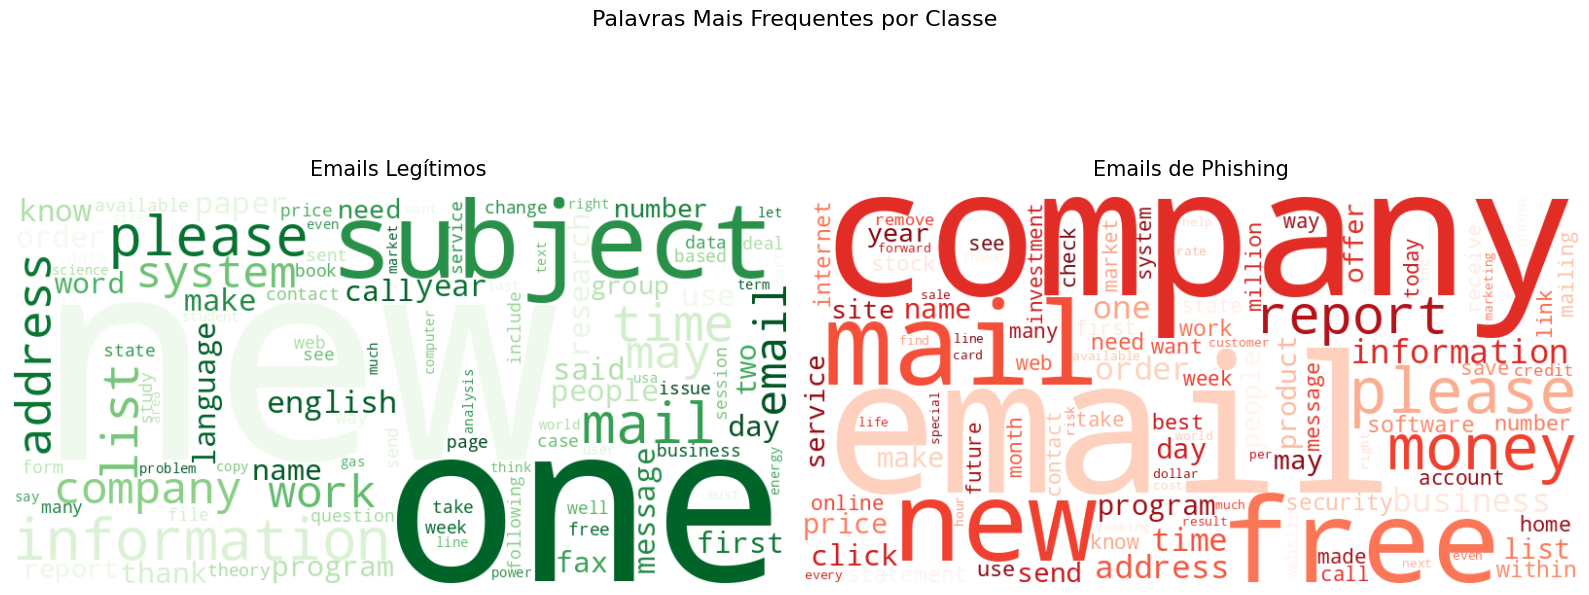

In [12]:
# Nuvem de Palavras por Classe
# Mostra visualmente as palavras mais frequentes em cada classe.
# Palavras maiores = mais frequentes.

from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, label, color, title in zip(
    axes,
    ["Safe Email",    "Phishing Email"],
    ["Greens",        "Reds"],
    ["Emails Legítimos", "Emails de Phishing"]
):
    texto_unido = " ".join(df[df["Email Type"] == label]["clean_text"])

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap=color,
        max_words=100,
        collocations=False   # evita bigramas duplicados
    ).generate(texto_unido)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=15, pad=15)

plt.suptitle("Palavras Mais Frequentes por Classe", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

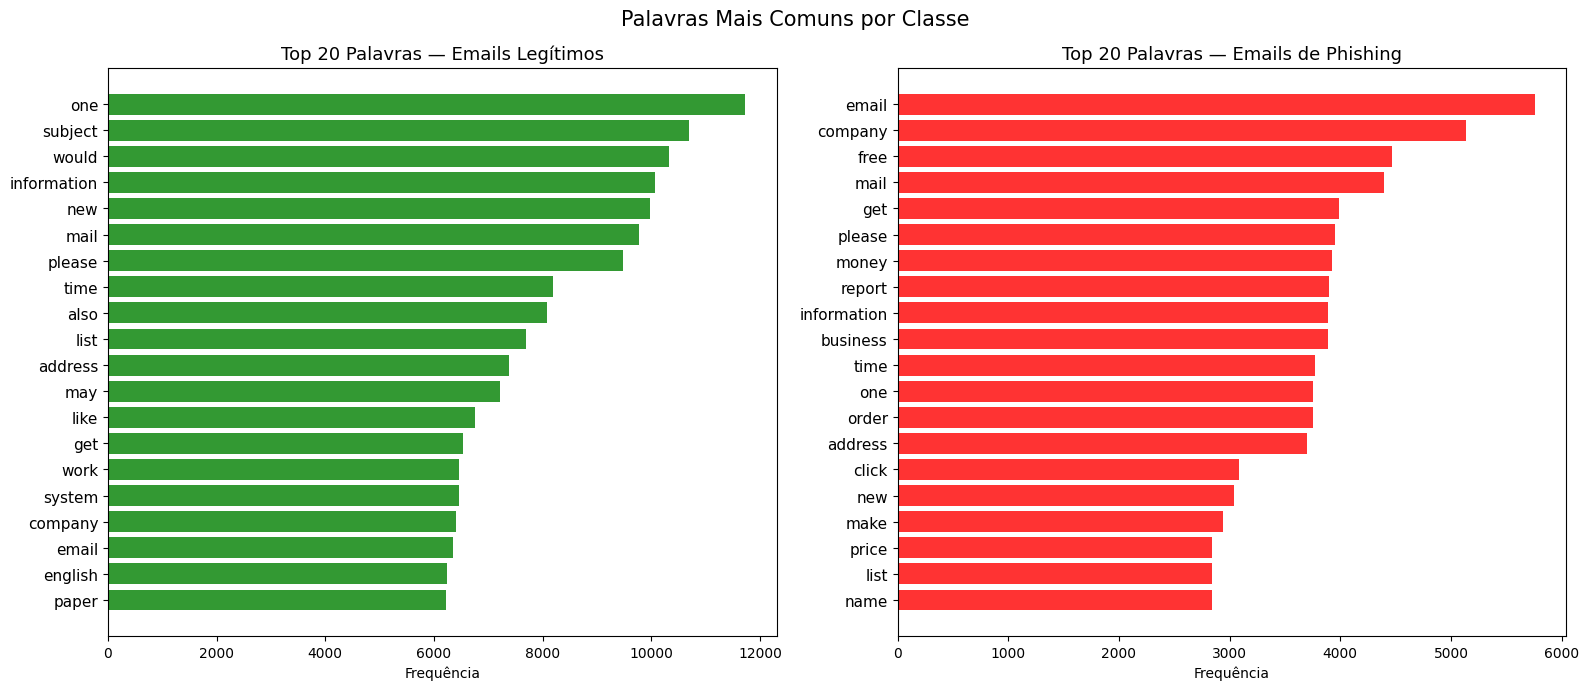

In [13]:
# Top 20 palavras mais frequentes por classe
# Confirma numericamente o que a nuvem mostra visualmente.


from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, label, color, title in zip(
    axes,
    ["Safe Email",         "Phishing Email"],
    ["green",            "red"],
    ["Emails Legítimos",   "Emails de Phishing"]
):
    # Contar palavras
    todas_palavras = " ".join(df[df["Email Type"] == label]["clean_text"]).split()
    top_words = Counter(todas_palavras).most_common(20)
    palavras, contagens = zip(*top_words)

    # Plotar
    ax.barh(range(20), contagens, color=color, alpha=0.8)
    ax.set_yticks(range(20))
    ax.set_yticklabels(palavras, fontsize=11)
    ax.invert_yaxis()   # palavra mais frequente no topo
    ax.set_title(f"Top 20 Palavras — {title}", fontsize=13)
    ax.set_xlabel("Frequência")

plt.suptitle("Palavras Mais Comuns por Classe", fontsize=15)
plt.tight_layout()
plt.savefig("top_palavras.png", dpi=150, bbox_inches="tight")
plt.show()

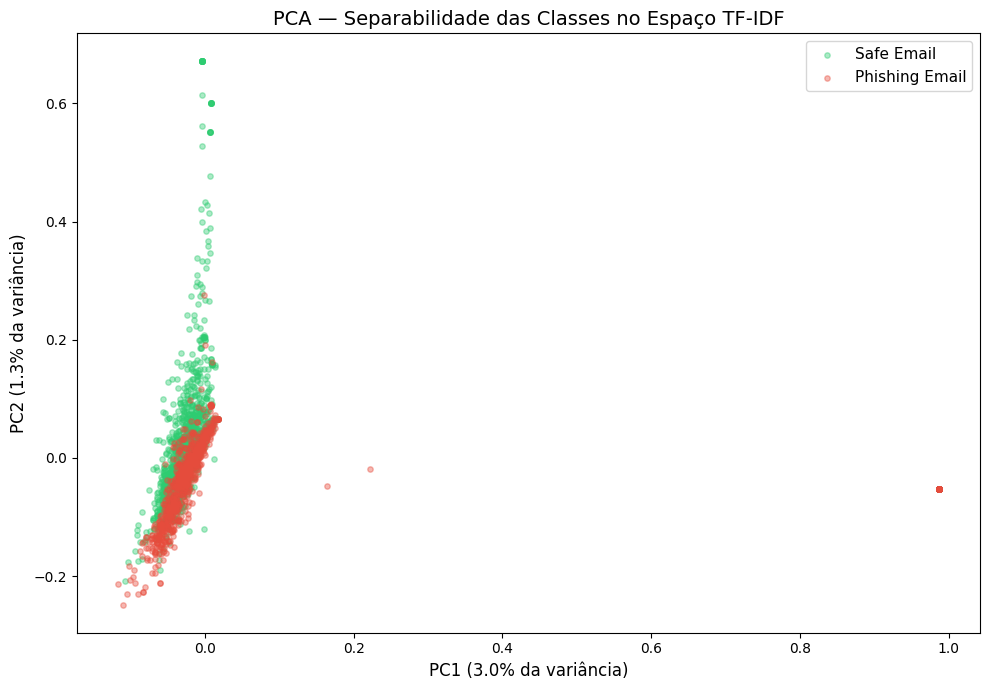


Variância explicada pelo PC1: 3.0%
Variância explicada pelo PC2: 1.3%
Total explicado pelos 2 componentes: 4.3%


In [14]:
# PCA — Visualizar separabilidade dos dados
# Usamos TF-IDF para vetorizar e PCA para reduzir para 2D.
# Se as classes formarem grupos separados no gráfico,
# os modelos de ML terão facilidade em classificar.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import numpy as np

# Amostra para tornar viável computacionalmente
amostra = df.sample(n=2000, random_state=42)

# Vetorizar com TF-IDF
tfidf = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf.fit_transform(amostra["clean_text"])

# Reduzir para 2 dimensões com PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())

variancia = pca.explained_variance_ratio_ * 100

# Plotar
fig, ax = plt.subplots(figsize=(10, 7))

cores   = {0: "#2ecc71", 1: "#e74c3c"}
rotulos = {0: "Safe Email", 1: "Phishing Email"}

for classe in [0, 1]:
    mask = amostra["label"].values == classe
    ax.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=cores[classe],
        label=rotulos[classe],
        alpha=0.4,
        s=15
    )

ax.set_xlabel(f"PC1 ({variancia[0]:.1f}% da variância)", fontsize=12)
ax.set_ylabel(f"PC2 ({variancia[1]:.1f}% da variância)", fontsize=12)
ax.set_title("PCA — Separabilidade das Classes no Espaço TF-IDF", fontsize=14)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("pca_scatter.png", dpi=150)
plt.show()

print(f"\nVariância explicada pelo PC1: {variancia[0]:.1f}%")
print(f"Variância explicada pelo PC2: {variancia[1]:.1f}%")
print(f"Total explicado pelos 2 componentes: {sum(variancia):.1f}%")

# Vetorização com TF-IDF

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,  # manter só as 10.000 palavras mais relevantes
                         # evita vocabulário gigante e overfitting

    ngram_range=(1, 2),  # usar unigramas E bigramas
                         # unigrama:  "free", "money"
                         # bigrama:   "free money", "click here"
                         # bigramas capturam contexto que unigramas perdem

    min_df=3,            # ignorar palavras que aparecem em menos de 3 emails
                         # remove palavras raríssimas que não generalizam

    max_df=0.95,         # ignorar palavras que aparecem em mais de 95% dos emails
                         # remove palavras ubíquas que não discriminam
)

# Aplicar nos textos limpos
X = tfidf.fit_transform(df["clean_text"])
y = df["label"]

print(f"Shape: {X.shape}")
print(f"   → {X.shape[0]} emails")
print(f"   → {X.shape[1]} features (palavras/bigramas)")

# Ver algumas features geradas
features = tfidf.get_feature_names_out()
print(f"\n Primeiras 20 features: {list(features[:20])}")
print(f" Últimas  20 features:  {list(features[-20:])}")

Shape: (18627, 10000)
   → 18627 emails
   → 10000 features (palavras/bigramas)

 Primeiras 20 features: ['aaa', 'abacha', 'abandoned', 'ability', 'able', 'aboriginal', 'abroad', 'absence', 'absolute', 'absolutely', 'absolutely free', 'absolutely nothing', 'abstract', 'abstract invited', 'abstract may', 'abstract must', 'abstract paper', 'abstract sent', 'abstract submitted', 'abuse']
 Últimas  20 features:  ['young', 'young researcher', 'younger', 'youth', 'yuen', 'yuen ren', 'zdnet', 'zealand', 'zero', 'zhang', 'zimbabwe', 'zimin', 'zip', 'zip code', 'zip phone', 'zone', 'zoom', 'zum', 'zur', 'zurich']


# Dividindo Train/Test set

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,                    # matriz TF-IDF (features)
    y,                    # labels (0 = safe, 1 = phishing)
    test_size=0.2,        # 20% para teste
    random_state=42,      
    stratify=y            # mantém proporção das classes
)

print(f"\n Treino: {X_train.shape[0]} emails ({X_train.shape[0]/X.shape[0]*100:.1f}%)")
print(f" Teste:  {X_test.shape[0]} emails ({X_test.shape[0]/X.shape[0]*100:.1f}%)")

# Verificar se o stratify funcionou
import pandas as pd
print("\n Proporção das classes no treino:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))
print("\n Proporção das classes no teste:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))


 Treino: 14901 emails (80.0%)
 Teste:  3726 emails (20.0%)

 Proporção das classes no treino:
label
0    0.608
1    0.392
Name: proportion, dtype: float64

 Proporção das classes no teste:
label
0    0.608
1    0.392
Name: proportion, dtype: float64


In [17]:
# Salvar pra não precisar rodar tudo de novo

import joblib
import scipy.sparse as sp

# Salvar o vetorizador treinado
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Salvar as matrizes esparsas
sp.save_npz("X_train.npz", X_train)
sp.save_npz("X_test.npz",  X_test)

# Salvar os labels
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv",   index=False)

# Testando modelos de ML tradicionais 

## Naive bayers


Naive Bayes
                precision    recall  f1-score   support

    Safe Email       0.97      0.97      0.97      2265
Phishing Email       0.95      0.95      0.95      1461

      accuracy                           0.96      3726
     macro avg       0.96      0.96      0.96      3726
  weighted avg       0.96      0.96      0.96      3726

  ROC-AUC: 0.9938


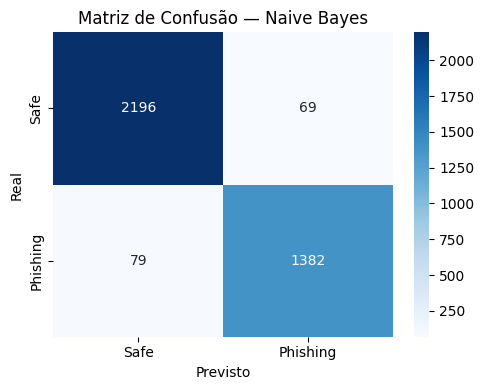

In [18]:
# MultinomialNB é a variante para contagens/frequências de texto.
# O parâmetro alpha é o "suavizador de Laplace":
#   evita probabilidade zero para palavras não vistas no treino.
#   alpha=1.0 é o valor padrão (suavização completa)

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)
import numpy as np

def avaliar_modelo(nome, modelo, X_test, y_test):
    """
    Avalia um modelo treinado e exibe:
    - Relatório de classificação (precision, recall, f1)
    - Matriz de confusão
    - ROC-AUC Score
    """
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]  # probabilidade da classe 1

    print(f"\n{'='*55}")
    print(f"{nome}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred,
          target_names=["Safe Email", "Phishing Email"]))
    print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Safe", "Phishing"],
                yticklabels=["Safe", "Phishing"], ax=ax)
    ax.set_title(f"Matriz de Confusão — {nome}")
    ax.set_ylabel("Real")
    ax.set_xlabel("Previsto")
    plt.tight_layout()
    plt.savefig(f"confusion_{nome.replace(' ','_')}.png", dpi=150)
    plt.show()

    return {
        "modelo":   nome,
        "y_pred":   y_pred,
        "y_proba":  y_proba,
    }

# Treinar
nb = MultinomialNB(alpha=1.0)
nb.fit(X_train, y_train)

# Avaliar
resultado_nb = avaliar_modelo("Naive Bayes", nb, X_test, y_test)

## Logistic regression


Logistic Regression
                precision    recall  f1-score   support

    Safe Email       0.97      0.97      0.97      2265
Phishing Email       0.96      0.95      0.96      1461

      accuracy                           0.96      3726
     macro avg       0.96      0.96      0.96      3726
  weighted avg       0.96      0.96      0.96      3726

  ROC-AUC: 0.9945


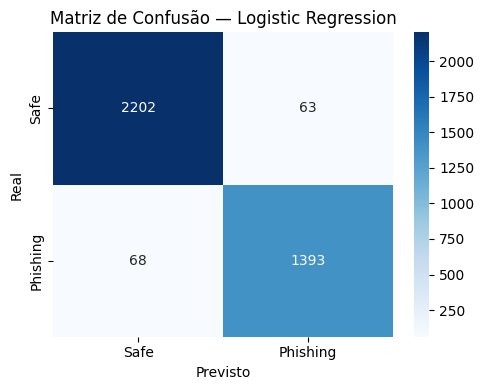

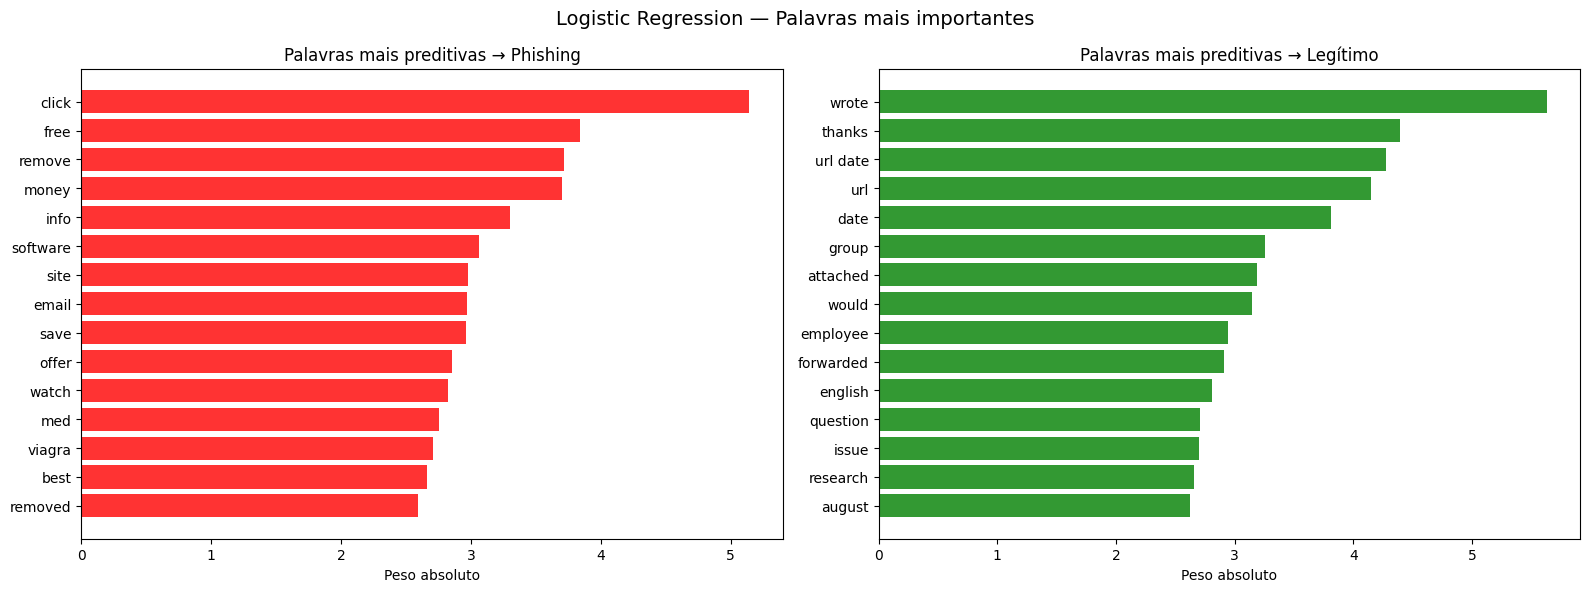

In [19]:
# C: parâmetro de regularização — controla overfitting
#   C pequeno → modelo mais simples (mais regularização)
#   C grande  → modelo mais complexo (menos regularização)
#
# max_iter: máximo de iterações para convergir
# solver:   algoritmo de otimização ('lbfgs' é bom para texto)

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=1.0,
                        max_iter=1000,
                        solver="lbfgs",
                        random_state=42)
lr.fit(X_train, y_train)

resultado_lr = avaliar_modelo("Logistic Regression", lr, X_test, y_test)

# ver as palavras mais importantes 
features    = tfidf.get_feature_names_out()
coeficientes = lr.coef_[0]

# Top 15 palavras que mais indicam PHISHING (coef positivo)
top_phishing = np.argsort(coeficientes)[-15:][::-1]
# Top 15 palavras que mais indicam EMAIL LEGÍTIMO (coef negativo)
top_legitimo = np.argsort(coeficientes)[:15]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, indices, color, title in zip(
    axes,
    [top_phishing,        top_legitimo],
    ["red",           "green"],
    ["→ Phishing",        "→ Legítimo"]
):
    palavras = [features[i] for i in indices]
    pesos    = [coeficientes[i] for i in indices]
    ax.barh(range(15), [abs(p) for p in pesos], color=color, alpha=0.8)
    ax.set_yticks(range(15))
    ax.set_yticklabels(palavras, fontsize=10)
    ax.invert_yaxis()
    ax.set_title(f"Palavras mais preditivas {title}", fontsize=12)
    ax.set_xlabel("Peso absoluto")

plt.suptitle("Logistic Regression — Palavras mais importantes", fontsize=14)
plt.tight_layout()
plt.savefig("lr_feature_importance.png", dpi=150)
plt.show()

## SVM


SVM
                precision    recall  f1-score   support

    Safe Email       0.98      0.97      0.97      2265
Phishing Email       0.96      0.97      0.96      1461

      accuracy                           0.97      3726
     macro avg       0.97      0.97      0.97      3726
  weighted avg       0.97      0.97      0.97      3726

  ROC-AUC: 0.9961


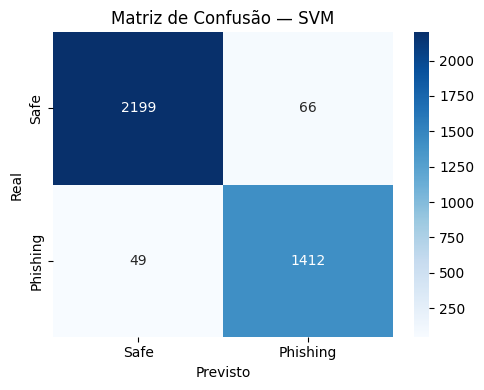

In [20]:
# LinearSVC é otimizado para texto (mais rápido que SVC kernel)
# C: mesma lógica da Logistic Regression
#   C pequeno → margem maior, mais erros tolerados (underfitting)
#   C grande  → margem menor, menos erros tolerados (overfitting)
#
# O CalibratedClassifierCV para obter probabilidades,
# pois o LinearSVC não as retorna nativamente.


from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_base = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm = CalibratedClassifierCV(svm_base)  # adiciona suporte a predict_proba
svm.fit(X_train, y_train)

resultado_svm = avaliar_modelo("SVM", svm, X_test, y_test)

## Decision tree


Decision Tree
                precision    recall  f1-score   support

    Safe Email       0.94      0.83      0.88      2265
Phishing Email       0.77      0.92      0.84      1461

      accuracy                           0.86      3726
     macro avg       0.86      0.87      0.86      3726
  weighted avg       0.87      0.86      0.86      3726

  ROC-AUC: 0.9130


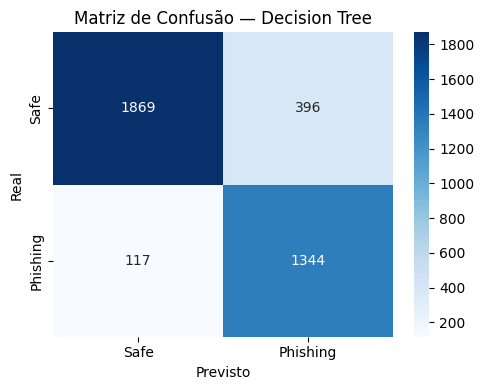


 Profundidade real da árvore: 20
 Número de folhas:             251


In [21]:
# max_depth: profundidade máxima da árvore
#   None    → cresce até pureza total (overfitting garantido)
#   10-20   → bom equilíbrio para dados de texto
#
# min_samples_split: mínimo de amostras para dividir um nó
#   valores maiores → árvore mais conservadora

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=20,
                             min_samples_split=10,
                             random_state=42)
dt.fit(X_train, y_train)

resultado_dt = avaliar_modelo("Decision Tree", dt, X_test, y_test)

# Profundidade real da árvore treinada
print(f"\n Profundidade real da árvore: {dt.get_depth()}")
print(f" Número de folhas:             {dt.get_n_leaves()}")

## Random Forest


Random Forest
                precision    recall  f1-score   support

    Safe Email       0.88      0.99      0.94      2265
Phishing Email       0.99      0.79      0.88      1461

      accuracy                           0.92      3726
     macro avg       0.94      0.89      0.91      3726
  weighted avg       0.92      0.92      0.91      3726

  ROC-AUC: 0.9895


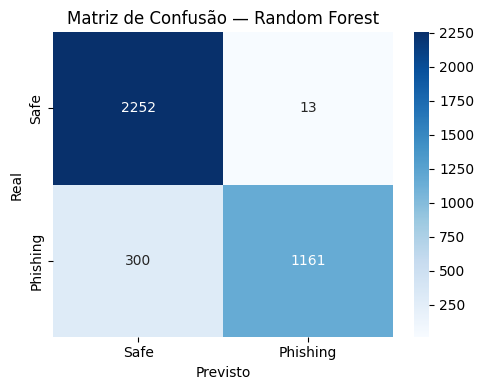

In [22]:
# n_estimators: número de árvores na floresta
#   mais árvores → mais estável, mas mais lento
#   100-200 é um bom equilíbrio
#
# max_features: nº de features consideradas em cada divisão
#   "sqrt" → raiz quadrada do total (padrão, funciona bem)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,
                             max_features="sqrt",
                             max_depth=25,
                             random_state=42,
                             n_jobs=-1)
rf.fit(X_train, y_train)

resultado_rf = avaliar_modelo("Random Forest", rf, X_test, y_test)

## Comparação dos 5 modelos


 Tabela Comparativa:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Modelo                                                             
Naive Bayes            0.9603     0.9524  0.9459    0.9492   0.9938
Logistic Regression    0.9648     0.9567  0.9535    0.9551   0.9945
SVM                    0.9691     0.9553  0.9665    0.9609   0.9961
Decision Tree          0.8623     0.7724  0.9199    0.8397   0.9130
Random Forest          0.9160     0.9889  0.7947    0.8812   0.9895


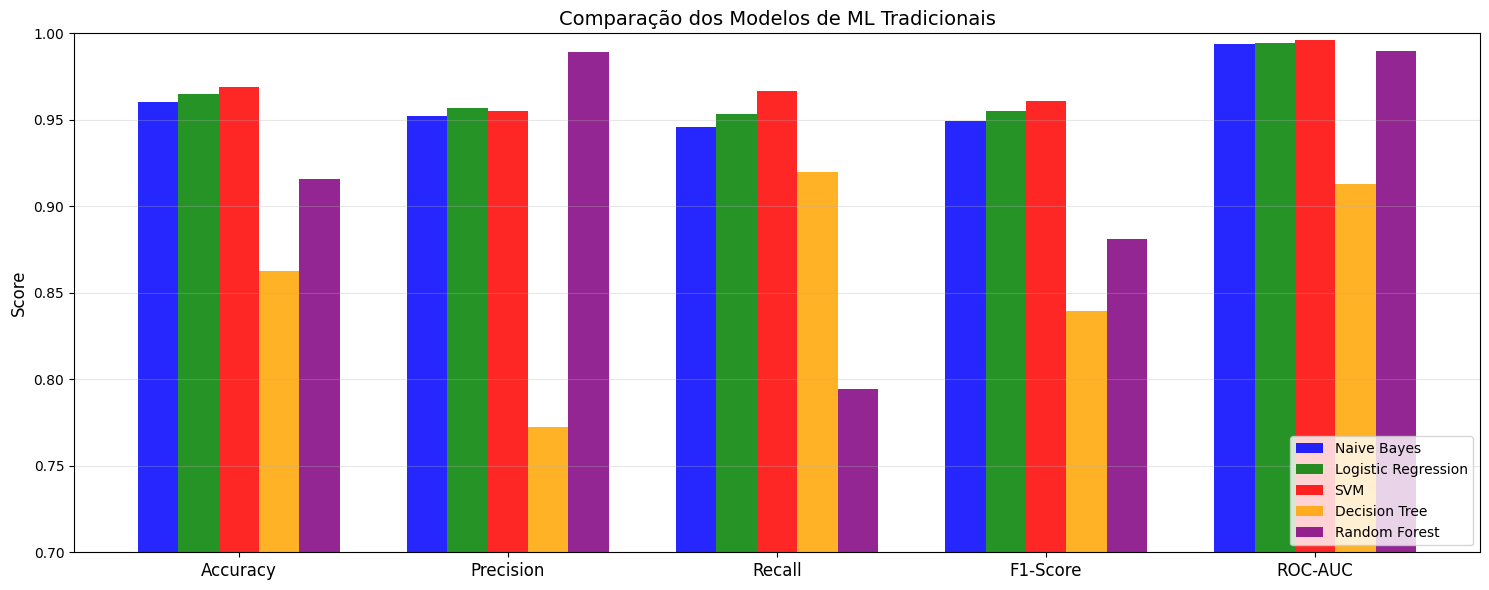


 Resultados salvos em 'resultados_ml_tradicionais.csv'


In [23]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score,  f1_score,
                              roc_auc_score)

modelos   = [("Naive Bayes",        nb),
             ("Logistic Regression", lr),
             ("SVM",                 svm),
             ("Decision Tree",       dt),
             ("Random Forest",       rf)]

resultados = []

for nome, modelo in modelos:
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]

    resultados.append({
        "Modelo":    nome,
        "Accuracy":  accuracy_score(y_test,  y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test,    y_pred),
        "F1-Score":  f1_score(y_test,        y_pred),
        "ROC-AUC":   roc_auc_score(y_test,   y_proba),
    })

df_resultados = pd.DataFrame(resultados).set_index("Modelo")
print("\n Tabela Comparativa:")
print(df_resultados.round(4).to_string())

# Gráfico comparativo 
metricas = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
x = np.arange(len(metricas))
largura = 0.15

fig, ax = plt.subplots(figsize=(15, 6))
cores = ["blue", "green", "red", "orange", "purple"]

for i, (nome, row) in enumerate(df_resultados.iterrows()):
    ax.bar(x + i * largura,
           [row[m] for m in metricas],
           largura,
           label=nome,
           color=cores[i],
           alpha=0.85)

ax.set_xticks(x + largura * 2)
ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylim(0.7, 1.0)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Comparação dos Modelos de ML Tradicionais", fontsize=14)
ax.legend(loc="lower right", fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("comparacao_modelos_ml.png", dpi=150)
plt.show()

# Salvar resultados para comparação futura com EL e RoBERTa
df_resultados.to_csv("resultados_ml_tradicionais.csv")
print("\n Resultados salvos em 'resultados_ml_tradicionais.csv'")

### Após análise do logistic regression, percebe-se nomes de funcionarios que podem estar enviesando o dataset

In [24]:
#vies_residual = {
#    "vince", "louise", "houston", "kaminski",
#    "john", "robert", "david", "mark", "mike",
#    "hou", "ena", "corp",
#}
#custom_stopwords |= vies_residual

# Reimplementação usando nova pipeline

In [25]:
# Tentando corrigir:
#   1. Instabilidade do split único     → 5-fold CV
#   2. Data leakage do TF-IDF           → Pipeline
#   3. Hiperparâmetros sem validação    → GridSearchCV


import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

# Dados brutos (texto, não matriz TF-IDF) 
X_raw = df["clean_text"].values
y     = df["label"].values

# Estratégia de CV estratificada 
# Estratificada = mantém proporção das classes em cada fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Métricas a calcular em cada fold 
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

# Parâmetros TF-IDF 
tfidf_params = dict(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95
)

# Definição dos pipelines 
pipelines = {
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   MultinomialNB(alpha=1.0))
    ]),

    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   LogisticRegression(C=1.0,
                                     max_iter=1000,
                                     solver="lbfgs",
                                     random_state=42))
    ]),

    "SVM": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   CalibratedClassifierCV(
                      LinearSVC(C=1.0,
                                max_iter=2000,
                                random_state=42)))
    ]),

    "Decision Tree": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   DecisionTreeClassifier(max_depth=15,
                                          min_samples_split=10,
                                          random_state=42))
    ]),

    "Random Forest": Pipeline([
        ("tfidf", TfidfVectorizer(**tfidf_params)),
        ("clf",   RandomForestClassifier(n_estimators=100,
                                          max_features="sqrt",
                                          max_depth=20,
                                          random_state=42,
                                          n_jobs=-1))
    ]),
}

# Rodar CV para todos os modelos 
resultados_cv = {}

for nome, pipeline in pipelines.items():
    print(f"Treinando {nome}...")

    scores = cross_validate(
        pipeline,
        X_raw, y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,          # paraleliza os folds
        return_train_score=True  # também avalia no treino (detecta overfitting)
    )

    resultados_cv[nome] = scores
    print(f"    F1: {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")

Treinando Naive Bayes...
    F1: 0.9416 ± 0.0027
Treinando Logistic Regression...
    F1: 0.9500 ± 0.0049
Treinando SVM...
    F1: 0.9572 ± 0.0031
Treinando Decision Tree...
    F1: 0.8060 ± 0.0039
Treinando Random Forest...
    F1: 0.8424 ± 0.0048


## Visualizando novos resultados

In [26]:
# TABELA COMPARATIVA COM MÉDIA ± DESVIO PADRÃO
# O desvio padrão é tão importante quanto a média!
# Um modelo com F1=0.96 ± 0.001 é muito mais confiável
# que um com F1=0.96 ± 0.02


linhas = []

for nome, scores in resultados_cv.items():
    linhas.append({
        "Modelo":      nome,
        "Accuracy":    f"{scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}",
        "Precision":   f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
        "Recall":      f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
        "F1-Score":    f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
        "ROC-AUC":     f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
        # Overfitting check: diferença entre treino e teste
        "F1 Treino":   f"{scores['train_f1'].mean():.4f}",
        "Overfitting": f"{(scores['train_f1'].mean() - scores['test_f1'].mean()):.4f}",
    })

df_cv = pd.DataFrame(linhas).set_index("Modelo")
print("Resultados Cross-Validation:")
print(df_cv.to_string())

df_cv.to_csv("resultados_cv.csv")

Resultados Cross-Validation:
                            Accuracy        Precision           Recall         F1-Score          ROC-AUC F1 Treino Overfitting
Modelo                                                                                                                        
Naive Bayes          0.9544 ± 0.0021  0.9451 ± 0.0026  0.9381 ± 0.0047  0.9416 ± 0.0027  0.9923 ± 0.0007    0.9507      0.0090
Logistic Regression  0.9608 ± 0.0038  0.9510 ± 0.0043  0.9489 ± 0.0078  0.9500 ± 0.0049  0.9937 ± 0.0008    0.9661      0.0162
SVM                  0.9662 ± 0.0024  0.9507 ± 0.0036  0.9637 ± 0.0047  0.9572 ± 0.0031  0.9954 ± 0.0006    0.9841      0.0269
Decision Tree        0.8292 ± 0.0042  0.7270 ± 0.0066  0.9042 ± 0.0038  0.8060 ± 0.0039  0.8962 ± 0.0061    0.8427      0.0367
Random Forest        0.8920 ± 0.0030  0.9852 ± 0.0044  0.7358 ± 0.0067  0.8424 ± 0.0048  0.9858 ± 0.0007    0.8763      0.0339


/tmp/ipykernel_265691/81774105.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados,
/tmp/ipykernel_265691/81774105.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados,


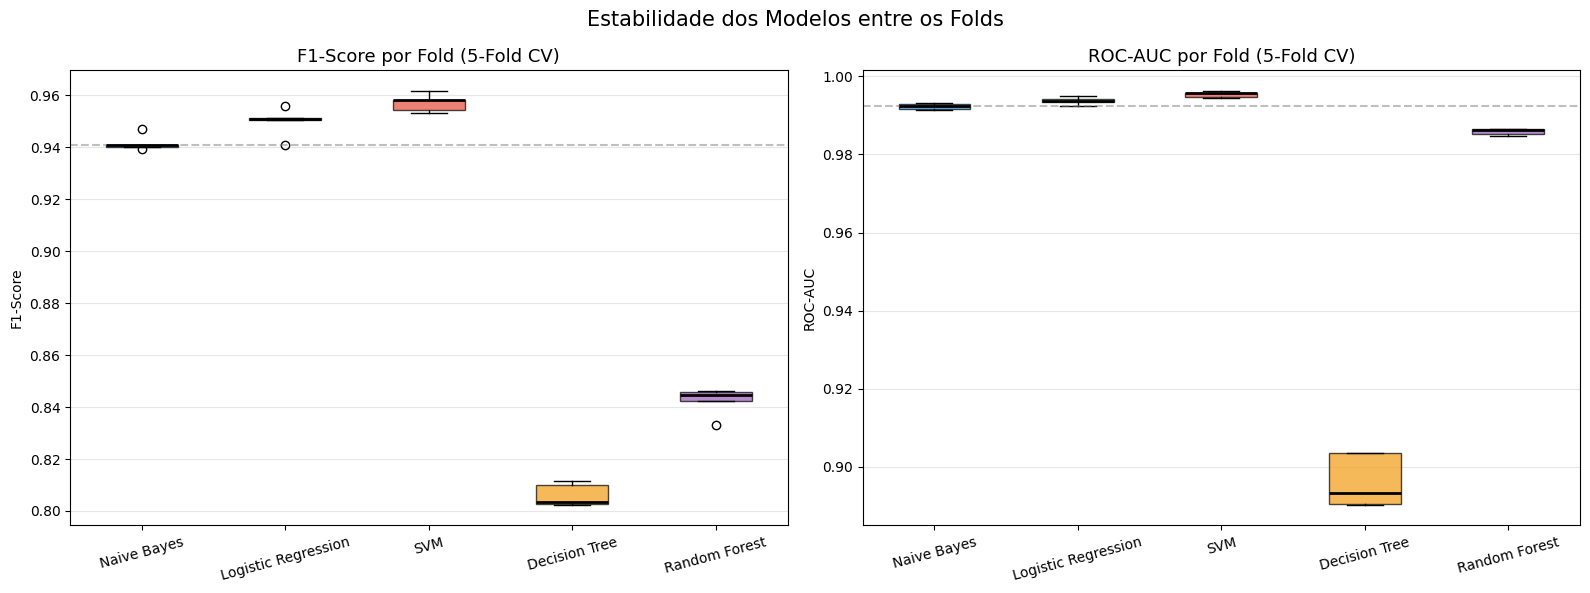

In [27]:
# BOXPLOT DOS FOLDS — Variabilidade entre folds
# Este gráfico mostra se o modelo é estável entre os folds
# ou se tem alta variância.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metricas_plot = {
    "F1-Score": "test_f1",
    "ROC-AUC":  "test_roc_auc"
}

for ax, (metrica_nome, metrica_key) in zip(axes, metricas_plot.items()):
    dados = [resultados_cv[nome][metrica_key] for nome in pipelines]
    nomes = list(pipelines.keys())

    bp = ax.boxplot(dados,
                    labels=nomes,
                    patch_artist=True,
                    medianprops={"color": "black", "linewidth": 2})

    cores = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12", "#9b59b6"]
    for patch, cor in zip(bp["boxes"], cores):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)

    ax.set_title(f"{metrica_nome} por Fold (5-Fold CV)", fontsize=13)
    ax.set_ylabel(metrica_nome)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", alpha=0.3)

    # Linha de referência na mediana geral
    todas = [v for d in dados for v in d]
    ax.axhline(np.median(todas), linestyle="--",
               color="gray", alpha=0.5, label="Mediana geral")

plt.suptitle("Estabilidade dos Modelos entre os Folds", fontsize=15)
plt.tight_layout()
plt.savefig("cv_boxplot.png", dpi=150)
plt.show()

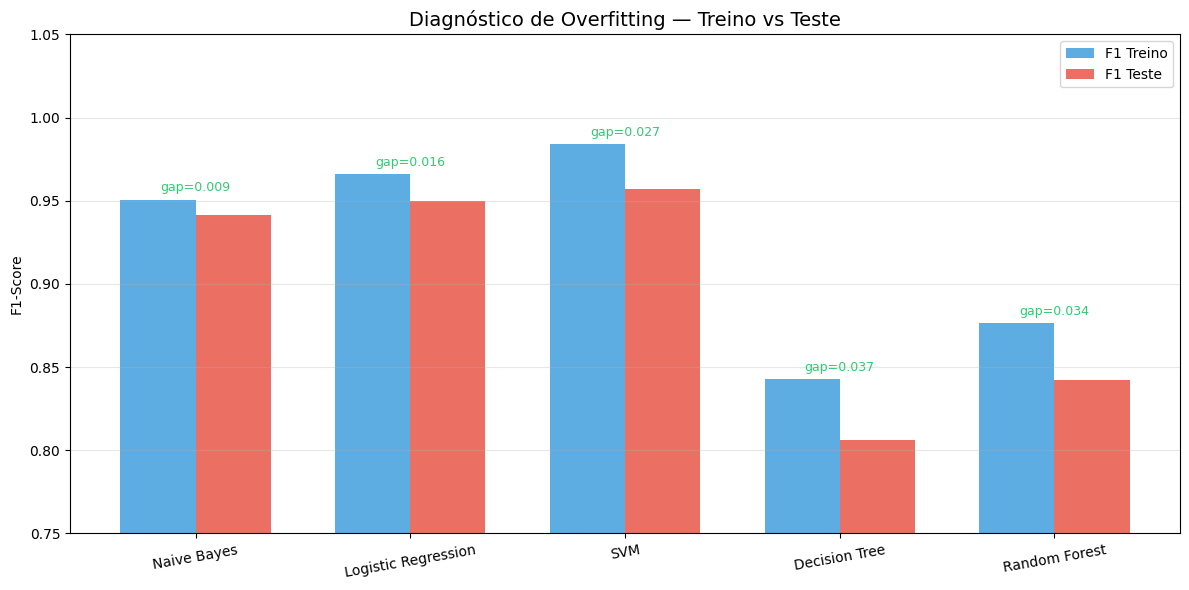

In [28]:
# DIAGNÓSTICO DE OVERFITTING
# Overfitting = modelo vai muito bem no treino mas mal no teste
# Gap pequeno (< 0.02) → modelo generaliza bem
# Gap grande (> 0.05)  → modelo memorizou o treino


fig, ax = plt.subplots(figsize=(12, 6))

nomes = list(pipelines.keys())
x     = np.arange(len(nomes))
w     = 0.35

f1_treino = [resultados_cv[n]["train_f1"].mean() for n in nomes]
f1_teste  = [resultados_cv[n]["test_f1"].mean()  for n in nomes]
gaps      = [t - v for t, v in zip(f1_treino, f1_teste)]

bars_train = ax.bar(x - w/2, f1_treino, w,
                    label="F1 Treino",  color="#3498db", alpha=0.8)
bars_test  = ax.bar(x + w/2, f1_teste,  w,
                    label="F1 Teste",   color="#e74c3c", alpha=0.8)

# Anotar o gap
for i, (xt, gap) in enumerate(zip(x, gaps)):
    cor   = "#e74c3c" if gap > 0.05 else "#2ecc71"
    label = f"gap={gap:.3f}"
    ax.annotate(label, (xt, max(f1_treino[i], f1_teste[i]) + 0.005),
                ha="center", fontsize=9, color=cor)

ax.set_xticks(x)
ax.set_xticklabels(nomes, rotation=10)
ax.set_ylim(0.75, 1.05)
ax.set_ylabel("F1-Score")
ax.set_title("Diagnóstico de Overfitting — Treino vs Teste", fontsize=14)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("overfitting_diagnostico.png", dpi=150)
plt.show()

# Utilizando o Ensemble learning 

## Usando o método voting

In [29]:
# Os 3 melhores modelos da etapa anterior:
# Naive Bayes, Logistic Regression e SVM.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score)

# Dados 
X_raw = df["clean_text"].values
y     = df["label"].values

# CV estratificado 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Parâmetros TF-IDF 
tfidf_params = dict(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95
)

# Base classifiers (cada um com seu próprio TF-IDF no pipeline) ---
# IMPORTANTE: cada modelo precisa do seu próprio TF-IDF dentro do pipeline
# O VotingClassifier não aceita pipelines diretamente com TF-IDF compartilhado
# pois cada estimador precisa ser independente

nb_clf  = Pipeline([("tfidf", TfidfVectorizer(**tfidf_params)),
                    ("clf",   MultinomialNB(alpha=1.0))])

lr_clf  = Pipeline([("tfidf", TfidfVectorizer(**tfidf_params)),
                    ("clf",   LogisticRegression(C=1.0,
                                                  max_iter=1000,
                                                  random_state=42))])

svm_clf = Pipeline([("tfidf", TfidfVectorizer(**tfidf_params)),
                    ("clf",   CalibratedClassifierCV(
                                  LinearSVC(C=1.0,
                                            max_iter=2000,
                                            random_state=42)))])

# Hard Voting 
hard_voting = VotingClassifier(
    estimators=[("nb", nb_clf), ("lr", lr_clf), ("svm", svm_clf)],
    voting="hard"      # decisão por maioria de votos binários
)

# Soft Voting 
soft_voting = VotingClassifier(
    estimators=[("nb", nb_clf), ("lr", lr_clf), ("svm", svm_clf)],
    voting="soft"      # decisão pela média das probabilidades
)

# Métricas sem roc_auc para Hard Voting
scoring_sem_auc = ["accuracy", "precision", "recall", "f1"]

# Métricas completas para Soft Voting
scoring_completo = ["accuracy", "precision", "recall", "f1", "roc_auc"]

print("Avaliando Hard Voting...")
scores_hard = cross_validate(hard_voting, X_raw, y,
                              cv=cv,
                              scoring=scoring_sem_auc,  # <- sem roc_auc
                              n_jobs=-1,
                              return_train_score=True)

print("Avaliando Soft Voting...")
scores_soft = cross_validate(soft_voting, X_raw, y,
                              cv=cv,
                              scoring=scoring_completo,  # <- com roc_auc
                              n_jobs=-1,
                              return_train_score=True)

# Adicionar roc_auc manualmente para Hard Voting usando cross_val_predict
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score

# Hard Voting não tem predict_proba, então calculamos
# o ROC-AUC usando as previsões binárias (menos preciso, mas possível)
y_pred_hard = cross_val_predict(hard_voting, X_raw, y, cv=cv, n_jobs=-1)

# ROC-AUC com predições binárias (equivale a usar threshold fixo de 0.5)
auc_hard = roc_auc_score(y, y_pred_hard)

print(f"\nHard Voting — F1:      {scores_hard['test_f1'].mean():.4f} ± {scores_hard['test_f1'].std():.4f}")
print(f"Hard Voting — ROC-AUC: {auc_hard:.4f} (threshold fixo 0.5)")
print(f"Soft Voting — F1:      {scores_soft['test_f1'].mean():.4f} ± {scores_soft['test_f1'].std():.4f}")
print(f"Soft Voting — ROC-AUC: {scores_soft['test_roc_auc'].mean():.4f} ± {scores_soft['test_roc_auc'].std():.4f}")

Avaliando Hard Voting...
Avaliando Soft Voting...

Hard Voting — F1:      0.9535 ± 0.0040
Hard Voting — ROC-AUC: 0.9619 (threshold fixo 0.5)
Soft Voting — F1:      0.9564 ± 0.0035
Soft Voting — ROC-AUC: 0.9949 ± 0.0006


## Utilizando o boosting

In [30]:
# XGBoost: Extreme Gradient Boosting
#   - Cada modelo corrige os RESÍDUOS (erros) do anterior
#   - Usa gradiente descendente para minimizar a loss function
#   - É o algoritmo mais vencedor em competições de ML com dados tabulares
#
# AdaBoost: Adaptive Boosting
#   - Cada modelo foca nos exemplos MAL classificados pelo anterior
#   - Mais antigo que XGBoost, mais simples de entender
#   - Usa árvores de profundidade 1 (stumps) como weak learners
#
# NOTA: Boosting não aceita matriz esparsa diretamente de forma eficiente
# Usamos SVD para reduzir dimensionalidade antes do boosting


from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.decomposition import TruncatedSVD
from xgboost import XGBClassifier

# --- Pipeline com redução dimensional para Boosting ---
# TF-IDF gera 10.000 features esparsas
# Boosting funciona melhor com features densas e em menor número
# TruncatedSVD reduz para 300 componentes (como PCA mas para matrizes esparsas)

adaboost = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("svd",   TruncatedSVD(n_components=300, random_state=42)),
    ("clf",   AdaBoostClassifier(
                  n_estimators=100,    # número de weak learners
                  learning_rate=0.5,   # contribuição de cada árvore
                                       # menor = mais conservador
                  random_state=42
              ))
])

xgboost = Pipeline([
    ("tfidf", TfidfVectorizer(**tfidf_params)),
    ("svd",   TruncatedSVD(n_components=300, random_state=42)),
    ("clf",   XGBClassifier(
                  n_estimators=200,    # número de árvores
                  max_depth=4,         # profundidade de cada árvore
                                       # pequena de propósito (weak learner)
                  learning_rate=0.1,   # shrinkage — evita overfitting
                  subsample=0.8,       # usa 80% dos dados por árvore
                  colsample_bytree=0.8,# usa 80% das features por árvore
                  use_label_encoder=False,
                  eval_metric="logloss",
                  random_state=42,
                  n_jobs=-1
              ))
])

print("Avaliando AdaBoost...")
scores_ada = cross_validate(adaboost, X_raw, y,
                             cv=cv, scoring=scoring, n_jobs=-1,
                             return_train_score=True)

print("Avaliando XGBoost...")
scores_xgb = cross_validate(xgboost, X_raw, y,
                             cv=cv, scoring=scoring, n_jobs=-1,
                             return_train_score=True)

print(f"\nAdaBoost — F1: {scores_ada['test_f1'].mean():.4f} ± {scores_ada['test_f1'].std():.4f}")
print(f"XGBoost  — F1: {scores_xgb['test_f1'].mean():.4f} ± {scores_xgb['test_f1'].std():.4f}")

⏳ Avaliando AdaBoost...
⏳ Avaliando XGBoost...


/home/isaque/Documentos/machine_learning/env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:16:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/isaque/Documentos/machine_learning/env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:16:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/isaque/Documentos/machine_learning/env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:16:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/isaque/Documentos/machine_learning/env/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [00:16:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_


✅ AdaBoost — F1: 0.8924 ± 0.0050
✅ XGBoost  — F1: 0.9441 ± 0.0047


## Stacking

In [31]:
# StackingClassifier usa cross-val internamente para gerar
# as previsões dos base learners de forma honesta
# (out-of-fold predictions) — evita data leakage no meta-modelo


from sklearn.ensemble import StackingClassifier

# --- Base learners (nível 0) ---
base_learners = [
    ("nb",  Pipeline([("tfidf", TfidfVectorizer(**tfidf_params)),
                      ("clf",   MultinomialNB(alpha=1.0))])),

    ("lr",  Pipeline([("tfidf", TfidfVectorizer(**tfidf_params)),
                      ("clf",   LogisticRegression(C=1.0,
                                                    max_iter=1000,
                                                    random_state=42))])),

    ("svm", Pipeline([("tfidf", TfidfVectorizer(**tfidf_params)),
                      ("clf",   CalibratedClassifierCV(
                                    LinearSVC(C=1.0,
                                              max_iter=2000,
                                              random_state=42)))]))
]

# --- Meta-learner (nível 1) ---
# Logistic Regression é a escolha clássica para meta-learner:
# simples, interpretável e evita overfitting no segundo nível
meta_learner = LogisticRegression(C=1.0, max_iter=1000, random_state=42)

stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,               # folds para gerar out-of-fold predictions
    stack_method="predict_proba",  # usa probabilidades, não apenas classe
    n_jobs=-1,
    passthrough=False   # meta-learner recebe só previsões, não features originais
)

print("Avaliando Stacking (mais lento — treina múltiplos modelos)...")
scores_stack = cross_validate(stacking, X_raw, y,
                               cv=cv, scoring=scoring, n_jobs=-1,
                               return_train_score=True)

print(f"\nStacking — F1: {scores_stack['test_f1'].mean():.4f} ± {scores_stack['test_f1'].std():.4f}")

⏳ Avaliando Stacking (mais lento — treina múltiplos modelos)...

Stacking — F1: 0.9572 ± 0.0035


## Visualizando resultados

In [33]:
# TABELA COMPARATIVA 

def extrair_metricas(nome, scores, auc_manual=None):
    """
    Extrai métricas de forma segura, com fallback para
    modelos que não têm roc_auc nos scores do CV.
    """
    f1  = scores["test_f1"]
    acc = scores["test_accuracy"]
    pre = scores["test_precision"]
    rec = scores["test_recall"]

    # ROC-AUC pode estar no scores ou ser passado manualmente
    if "test_roc_auc" in scores:
        auc_mean = scores["test_roc_auc"].mean()
        auc_std  = scores["test_roc_auc"].std()
    elif auc_manual is not None:
        auc_mean = auc_manual
        auc_std  = 0.0  # calculado sem CV, sem std disponível
    else:
        auc_mean = float("nan")
        auc_std  = float("nan")

    return {
        "Modelo":      nome,
        "Accuracy":    f"{acc.mean():.4f} ± {acc.std():.4f}",
        "Precision":   f"{pre.mean():.4f} ± {pre.std():.4f}",
        "Recall":      f"{rec.mean():.4f} ± {rec.std():.4f}",
        "F1-Score":    f"{f1.mean():.4f} ± {f1.std():.4f}",
        "ROC-AUC":     f"{auc_mean:.4f}" + (f" ± {auc_std:.4f}" if auc_std > 0 else " *"),
        "Gap Overfit": f"{(scores['train_f1'].mean() - f1.mean()):.4f}",
        "Tipo":        "Ensemble Learning"
    }

linhas_el = [
    extrair_metricas("Hard Voting", scores_hard, auc_manual=auc_hard),
    extrair_metricas("Soft Voting", scores_soft),
    extrair_metricas("AdaBoost",    scores_ada),
    extrair_metricas("XGBoost",     scores_xgb),
    extrair_metricas("Stacking",    scores_stack),
]

df_el = pd.DataFrame(linhas_el).set_index("Modelo")
print("Resultados Ensemble Learning:")
print(df_el.drop(columns="Tipo").to_string())
print("\n* ROC-AUC calculado com threshold fixo 0.5, sem desvio padrão por fold")

📊 Resultados Ensemble Learning:
                    Accuracy        Precision           Recall         F1-Score          ROC-AUC Gap Overfit
Modelo                                                                                                      
Hard Voting  0.9635 ± 0.0031  0.9525 ± 0.0039  0.9546 ± 0.0056  0.9535 ± 0.0040         0.9619 *      0.0160
Soft Voting  0.9657 ± 0.0027  0.9542 ± 0.0030  0.9587 ± 0.0053  0.9564 ± 0.0035  0.9949 ± 0.0006      0.0189
AdaBoost     0.9164 ± 0.0036  0.9007 ± 0.0032  0.8843 ± 0.0081  0.8924 ± 0.0050  0.9723 ± 0.0014      0.0036
XGBoost      0.9557 ± 0.0037  0.9343 ± 0.0045  0.9540 ± 0.0066  0.9441 ± 0.0047  0.9923 ± 0.0012      0.0364
Stacking     0.9663 ± 0.0027  0.9537 ± 0.0029  0.9607 ± 0.0055  0.9572 ± 0.0035  0.9950 ± 0.0007      0.0205

* ROC-AUC calculado com threshold fixo 0.5, sem desvio padrão por fold


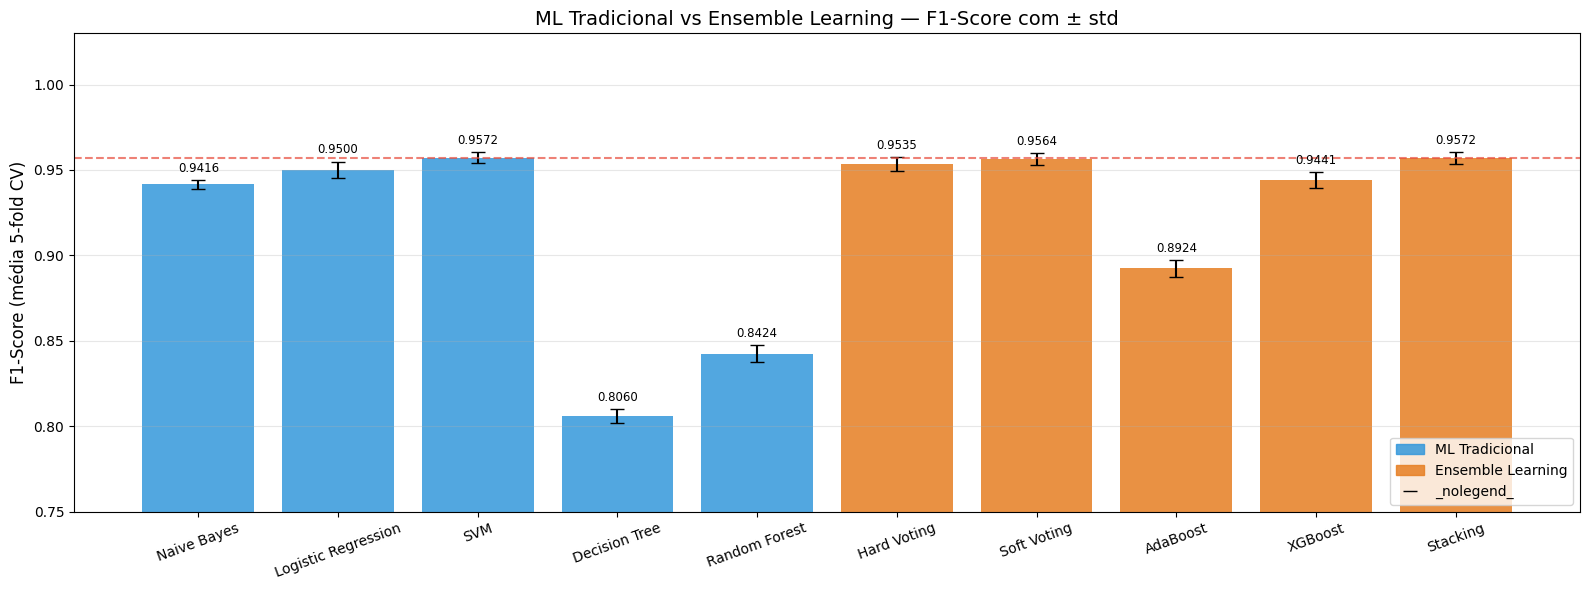

In [32]:
# Recuperar scores ML tradicionais do resultados_cv (Etapa 3)
todos = {
    # ML Tradicionais
    "Naive Bayes":         resultados_cv["Naive Bayes"],
    "Logistic Regression": resultados_cv["Logistic Regression"],
    "SVM":                 resultados_cv["SVM"],
    "Decision Tree":       resultados_cv["Decision Tree"],
    "Random Forest":       resultados_cv["Random Forest"],
    # Ensemble Learning
    "Hard Voting":         scores_hard,
    "Soft Voting":         scores_soft,
    "AdaBoost":            scores_ada,
    "XGBoost":             scores_xgb,
    "Stacking":            scores_stack,
}

nomes     = list(todos.keys())
f1_medias = [todos[n]["test_f1"].mean() for n in nomes]
f1_stds   = [todos[n]["test_f1"].std()  for n in nomes]

# Azul = ML Tradicional, Laranja = Ensemble
cores = ["#3498db"] * 5 + ["#e67e22"] * 5

fig, ax = plt.subplots(figsize=(16, 6))

bars = ax.bar(nomes, f1_medias, color=cores, alpha=0.85,
              yerr=f1_stds, capsize=5,
              error_kw={"linewidth": 1.5, "color": "black"})

# Linha de referência no melhor ML tradicional (SVM)
melhor_ml = max(todos[n]["test_f1"].mean() for n in list(todos)[:5])
ax.axhline(melhor_ml, linestyle="--", color="#e74c3c",
           linewidth=1.5, alpha=0.7,
           label=f"Melhor ML Tradicional — SVM: {melhor_ml:.4f}")

# Anotar valores nas barras
for bar, média, std in zip(bars, f1_medias, f1_stds):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + 0.003,
            f"{média:.4f}", ha="center", va="bottom", fontsize=8.5)

# Legenda
from matplotlib.patches import Patch
handles = [
    Patch(color="#3498db", alpha=0.85, label="ML Tradicional"),
    Patch(color="#e67e22", alpha=0.85, label="Ensemble Learning"),
    ax.get_lines()[0]
]
ax.legend(handles=handles, fontsize=10, loc="lower right")

ax.set_ylim(0.75, 1.03)
ax.set_ylabel("F1-Score (média 5-fold CV)", fontsize=12)
ax.set_title("ML Tradicional vs Ensemble Learning — F1-Score com ± std", fontsize=14)
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("ml_vs_el_comparacao.png", dpi=150)
plt.show()